# Klasifikasi Tangisan Bayi — Intermediate Fusion (Citra + Audio)

Pendekatan yang dipakai di notebook ini:

| Aspek | Keputusan |
|---|---|
| **Unit data** | **1 video = 1 sample** (beberapa frame diringkas jadi 1 vektor fitur, bukan dijadikan baris data terpisah) |
| **Cabang citra** | **Transfer learning** — backbone pretrained ImageNet yang dibekukan, hanya layer proyeksi kecil di atasnya yang dilatih |
| **Pooling antar-frame** | `POOLING = 'mean'` (rata-rata) atau `'attention'` (bobot antar-frame dipelajari model) — bisa dibandingkan |
| **Cabang audio** | CNN kecil dilatih dari nol, input **array log-mel mentah** (`.npy`, bukan gambar berwarna/PNG) |
| **Titik fusi** | `Concatenate` di level fitur → **intermediate / feature-level fusion** |
| **Split** | 3 arah — **test diambil langsung dari folder `data_test_video`** (bukan hasil pecahan acak), sisanya dipecah stratified-group jadi train/val |
| **Integritas dataset** | Hash SHA256 tiap video dicatat & diverifikasi ulang tiap run (`results/dataset_sha256.json`) |
| **Evaluasi test** | Dikunci — notebook menolak mengevaluasi ulang test set kalau hasilnya sudah pernah tersimpan |
| **Metrik** | Accuracy + **macro F1** (lebih adil saat jumlah data antar kelas tidak seimbang) |


In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display
import tensorflow as tf
from pathlib import Path
from moviepy import VideoFileClip
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns
import json

print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


## Konfigurasi

In [2]:
VIDEO_DIR = 'Data_Video_Bayi'
WORK_DIR  = 'work'
FRAME_DIR = os.path.join(WORK_DIR, 'frames')
SPEC_DIR  = os.path.join(WORK_DIR, 'spectrograms')

BACKBONE = 'resnet'
POOLING  = 'mean'
FRAME_SIZE = (224, 224)
N_CHANNELS = 3

SPEC_SIZE     = (64, 128)
SPEC_CHANNELS = 1

N_FRAMES_PER_VIDEO = 5
BATCH_SIZE = 64
EPOCHS     = 100
SEED       = 42

TRAIN_DIR_NAMES = ['data_train_video']
TEST_DIR_NAMES  = ['data_test_video']

CLASS_NAMES = ['eairh', 'eh', 'heh', 'neh', 'owh']
N_CLASSES   = len(CLASS_NAMES)

MEANINGS = {'eairh': 'Masuk angin', 'eh': 'Perlu bersendawa',
            'heh': 'Tidak nyaman', 'neh': 'Lapar', 'owh': 'Mengantuk'}

RESULTS_DIR = 'results'

for d in [FRAME_DIR, SPEC_DIR, RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)

tf.keras.utils.set_random_seed(SEED)

## Ekstraksi dari video

Tiap video menghasilkan **satu** sample: beberapa frame citra + **satu** spektogram dari audio penuh
(audio tidak dipotong per segmen, karena klip yang pendek bisa membuat pola tangisan terpenggal).

In [3]:
def extract_video_sample(video_path, frame_prefix, spec_prefix, n_frames=N_FRAMES_PER_VIDEO, frame_size=FRAME_SIZE):
    try:
        clip = VideoFileClip(video_path)
        audio = clip.audio
    except Exception as e:
        print(f"  Gagal load video: {Path(video_path).name} ({e})")
        return None
    if audio is None:
        clip.close()
        return None

    tmp_wav = f"{spec_prefix}_tmp.wav"
    audio.write_audiofile(tmp_wav, logger=None)
    clip.close()

    X, sr = librosa.load(tmp_wav, sr=None, res_type='kaiser_fast')
    os.remove(tmp_wav)
    if X.size == 0:
        return None

    S = librosa.feature.melspectrogram(y=X, sr=sr, n_mels=SPEC_SIZE[0])
    S_db = librosa.power_to_db(S, ref=np.max)
    S_db = (S_db - S_db.mean()) / (S_db.std() + 1e-6)     # normalisasi antar video

    S_resized = cv2.resize(S_db.astype(np.float32), (SPEC_SIZE[1], SPEC_SIZE[0]),
                           interpolation=cv2.INTER_LINEAR)
    spec_out = f"{spec_prefix}.npy"
    np.save(spec_out, np.flipud(S_resized).copy())

    # Beberapa frame tersebar merata di sepanjang durasi video
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS) or 25
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    duration = total / fps if fps > 0 else 0

    frame_paths = []
    for i in range(n_frames):
        target = duration * (i + 0.5) / n_frames if duration > 0 else 0.0
        cap.set(cv2.CAP_PROP_POS_MSEC, target * 1000)
        ok, frame = cap.read()
        if not ok:
            continue
        out = f"{frame_prefix}_f{i}.png"
        plt.imsave(out, cv2.cvtColor(cv2.resize(frame, frame_size), cv2.COLOR_BGR2RGB))
        frame_paths.append(out)
    cap.release()

    if not frame_paths:
        return None
    while len(frame_paths) < n_frames:      # Apabila klip sangat pendek, maka ulang frame terakhir
        frame_paths.append(frame_paths[-1])

    return frame_paths, spec_out


In [4]:
VIDEO_EXTENSIONS = ('.mp4', '.mov', '.avi', '.mkv')

def list_videos(class_dir, dir_names):
    found = []
    for name in dir_names:
        d = class_dir / name
        if d.is_dir():
            found += [p for p in d.glob('*') if p.suffix.lower() in VIDEO_EXTENSIONS]
    return found

samples = []

for class_name in CLASS_NAMES:
    class_dir = Path(VIDEO_DIR) / class_name
    if not class_dir.is_dir():
        print(f"Lewati (folder tidak ada): {class_dir}")
        continue

    train_videos = list_videos(class_dir, TRAIN_DIR_NAMES)
    test_videos  = list_videos(class_dir, TEST_DIR_NAMES)
    print(f"{class_name}: {len(train_videos)} video di folder train, {len(test_videos)} video di folder test")

    for origin, video_paths in [('trainval', train_videos), ('test', test_videos)]:
        for video_path in video_paths:
            stem = video_path.stem
            result = extract_video_sample(
                str(video_path),
                os.path.join(FRAME_DIR, f"{class_name}_{stem}"),
                os.path.join(SPEC_DIR, f"{class_name}_{stem}"),
            )
            if result is None:
                continue
            frame_paths, spec_path = result
            samples.append({'frame_paths': frame_paths, 'spec_path': spec_path,
                            'label': CLASS_NAMES.index(class_name),
                            'video_id': f"{class_name}_{stem}",
                            'origin': origin,
                            'source_path': str(video_path)})   # [BARU] untuk hash-check integritas dataset

df_samples = pd.DataFrame(samples)
print(f"\nTotal: {len(df_samples)} video = {len(df_samples)} sample\n")
print(pd.crosstab(df_samples['label'].map(dict(enumerate(CLASS_NAMES))), df_samples['origin']))

eairh: 9 video di folder train, 4 video di folder test
eh: 28 video di folder train, 7 video di folder test
heh: 28 video di folder train, 7 video di folder test
neh: 28 video di folder train, 7 video di folder test
owh: 28 video di folder train, 7 video di folder test

Total: 153 video = 153 sample

origin  test  trainval
label                 
eairh      4         9
eh         7        28
heh        7        28
neh        7        28
owh        7        28


### [BARU] Integritas dataset

Hitung hash SHA256 tiap video mentah dan simpan sebagai manifest. Kalau file manifest sudah ada dari
run sebelumnya, verifikasi ulang -- ini menjamin dataset yang dipakai untuk melatih model persis sama
antar-run (tidak ada video yang diam-diam berubah/terganti/corrupt), sekaligus dokumentasi untuk laporan.

In [5]:
import hashlib

def sha256_of(path, chunk_size=1 << 20):
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(chunk_size), b''):
            h.update(chunk)
    return h.hexdigest()

hash_manifest_path = os.path.join(RESULTS_DIR, 'dataset_sha256.json')
current_hashes = {row['video_id']: sha256_of(row['source_path']) for _, row in df_samples.iterrows()}

if os.path.exists(hash_manifest_path):
    recorded_hashes = json.load(open(hash_manifest_path))
    mismatched = [vid for vid, h in current_hashes.items()
                  if vid in recorded_hashes and recorded_hashes[vid] != h]
    missing    = [vid for vid in recorded_hashes if vid not in current_hashes]
    new_videos = [vid for vid in current_hashes if vid not in recorded_hashes]
    assert not mismatched, f"Dataset berubah dari run sebelumnya, video ini beda isinya: {mismatched}"
    if missing:
        print(f"Perhatian, {len(missing)} video di manifest lama sudah tidak ada lagi: {missing}")
    if new_videos:
        print(f"Ada {len(new_videos)} video baru dibanding manifest lama (akan ditambahkan): {new_videos}")
        recorded_hashes.update(current_hashes)
        json.dump(recorded_hashes, open(hash_manifest_path, 'w'), indent=2)
    print(f"OK -- {len(current_hashes)} video diverifikasi identik dengan manifest sebelumnya.")
else:
    json.dump(current_hashes, open(hash_manifest_path, 'w'), indent=2)
    print(f"Manifest baru dibuat: {hash_manifest_path} ({len(current_hashes)} video dicatat).")


Manifest baru dibuat: results\dataset_sha256.json (153 video dicatat).


### Periksa hasil ekstraksi secara visual

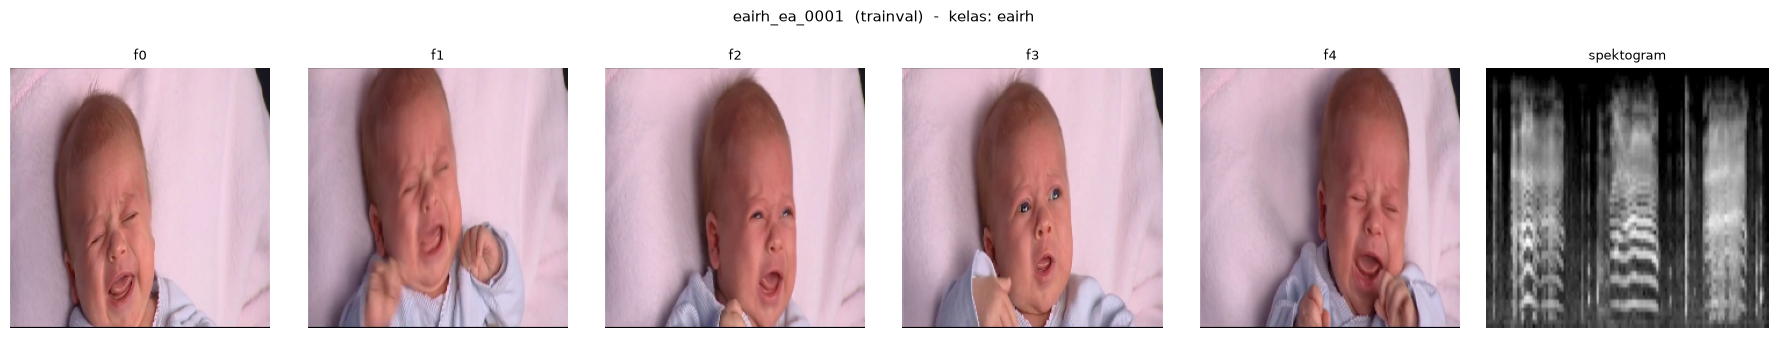

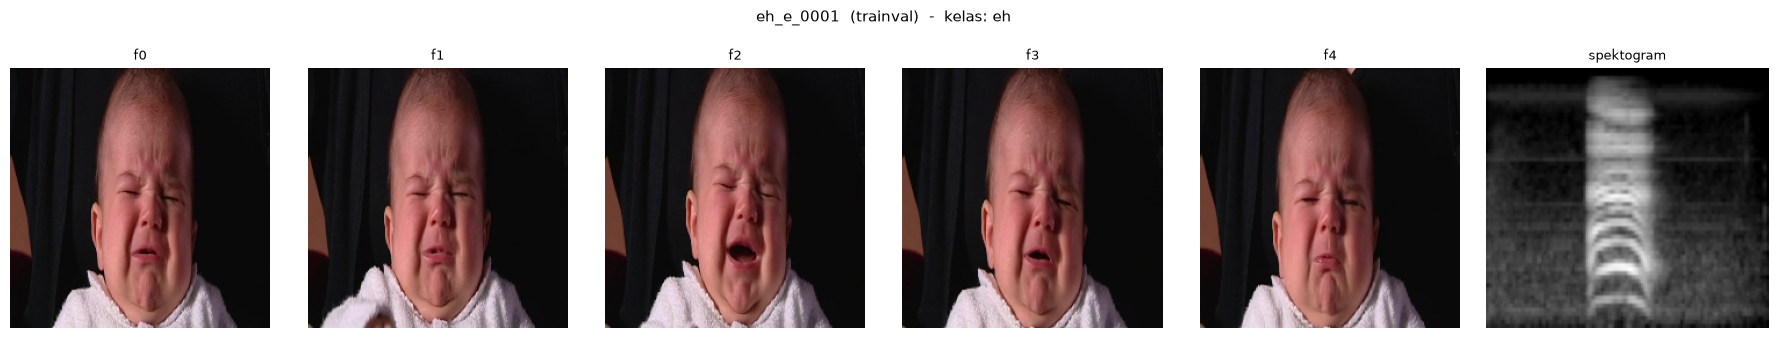

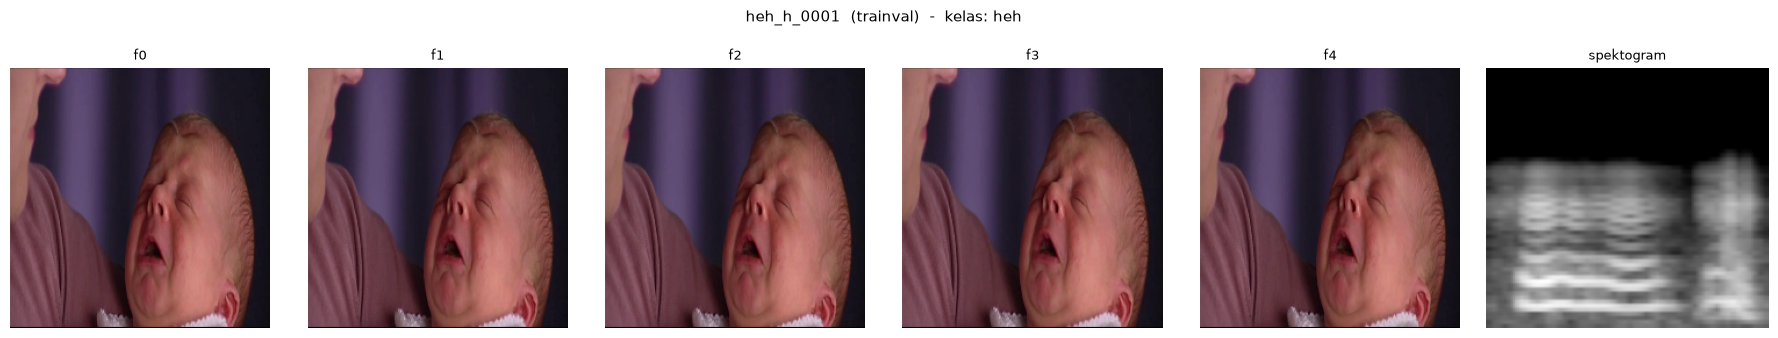

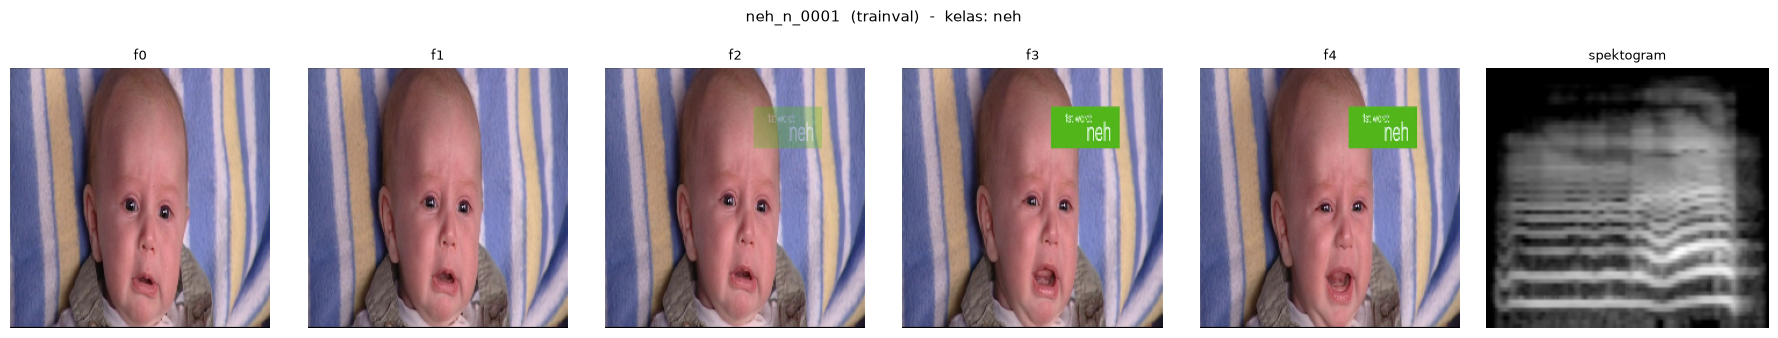

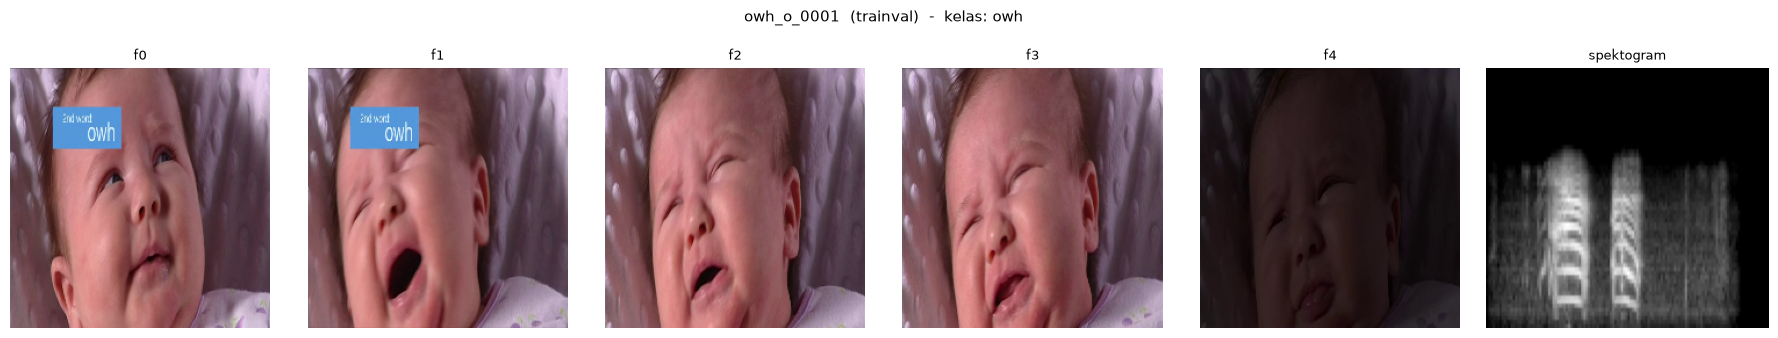

In [6]:
def preview_sample(row):
    """Tampilkan semua frame + spektogram dari satu video."""
    n = len(row['frame_paths'])
    fig, axes = plt.subplots(1, n + 1, figsize=(3 * (n + 1), 3.4))
    for i, p in enumerate(row['frame_paths']):
        axes[i].imshow(plt.imread(p))
        axes[i].set_title(f"f{i}", fontsize=9)
        axes[i].axis('off')

    spec_array = np.load(row['spec_path'])   # [FIX] sekarang .npy, bukan gambar
    axes[-1].imshow(spec_array, cmap='gray', aspect='auto')
    axes[-1].set_title('spektogram', fontsize=9)
    axes[-1].axis('off')

    fig.suptitle(f"{row['video_id']}  ({row['origin']})  -  kelas: {CLASS_NAMES[row['label']]}", fontsize=11)
    plt.tight_layout(); plt.show()

# Tampilkan satu contoh dari tiap kelas
for label in range(N_CLASSES):
    subset = df_samples[df_samples['label'] == label]
    if len(subset):
        preview_sample(subset.iloc[0])


## Split train / val / test

In [7]:
from sklearn.model_selection import GroupShuffleSplit

def group_split(df, test_size, seed):
    splitter = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
    idx_a, idx_b = next(splitter.split(df, groups=df['video_id']))
    return df.iloc[idx_a], df.iloc[idx_b]

def stratified_group_split(df, test_size, seed):
    parts_a, parts_b = [], []
    for label in sorted(df['label'].unique()):
        subset = df[df['label'] == label]
        a, b = group_split(subset, test_size=test_size, seed=seed)
        parts_a.append(a); parts_b.append(b)
    return pd.concat(parts_a).reset_index(drop=True), pd.concat(parts_b).reset_index(drop=True)

# test_df LANGSUNG dari folder data_test_video
test_df     = df_samples[df_samples['origin'] == 'test'].reset_index(drop=True)
trainval_df = df_samples[df_samples['origin'] == 'trainval'].reset_index(drop=True)

# trainval dipecah lagi jadi train dan val
train_df, valid_df = stratified_group_split(trainval_df, test_size=0.2, seed=SEED)

# Sanity check eksplisit: pastikan video_id di ketiga sisi benar-benar terpisah total
train_ids, valid_ids, test_ids = set(train_df['video_id']), set(valid_df['video_id']), set(test_df['video_id'])
assert not (train_ids & valid_ids), "Leakage: ada video yang sama di train & valid!"
assert not (train_ids & test_ids),  "Leakage: ada video yang sama di train & test!"
assert not (valid_ids & test_ids),  "Leakage: ada video yang sama di valid & test!"

for name, d in [('Train', train_df), ('Valid', valid_df), ('Test ', test_df)]:
    dist = d['label'].value_counts().sort_index().tolist()
    print(f"{name}: {len(d):3d} video   distribusi per kelas {dict(zip(CLASS_NAMES, dist))}")

Train:  95 video   distribusi per kelas {'eairh': 7, 'eh': 22, 'heh': 22, 'neh': 22, 'owh': 22}
Valid:  26 video   distribusi per kelas {'eairh': 2, 'eh': 6, 'heh': 6, 'neh': 6, 'owh': 6}
Test :  32 video   distribusi per kelas {'eairh': 4, 'eh': 7, 'heh': 7, 'neh': 7, 'owh': 7}


## Pipeline data

In [8]:
PREPROCESS = (tf.keras.applications.mobilenet_v2.preprocess_input if BACKBONE == 'mobilenet'
              else tf.keras.applications.resnet50.preprocess_input)

def load_frame(path):
    img = tf.image.decode_png(tf.io.read_file(path), channels=N_CHANNELS)
    img = tf.image.resize(img, FRAME_SIZE)
    return PREPROCESS(img)

def load_spec(path):
    def _load(p):
        arr = np.load(p.numpy().decode('utf-8')).astype(np.float32)
        return arr[..., np.newaxis]
    spec = tf.py_function(func=_load, inp=[path], Tout=tf.float32)
    spec.set_shape([*SPEC_SIZE, SPEC_CHANNELS])
    return spec

def spec_augment(img, max_mask_frac=0.08):
    h, w = tf.shape(img)[0], tf.shape(img)[1]
    max_f = tf.maximum(tf.cast(tf.cast(h, tf.float32) * max_mask_frac, tf.int32), 1)
    max_t = tf.maximum(tf.cast(tf.cast(w, tf.float32) * max_mask_frac, tf.int32), 1)

    f  = tf.random.uniform([], 0, max_f, dtype=tf.int32)
    f0 = tf.random.uniform([], 0, tf.maximum(h - f, 1), dtype=tf.int32)
    img = img * tf.reshape(tf.concat([tf.ones([f0]), tf.zeros([f]), tf.ones([h - f0 - f])], 0), [h, 1, 1])

    t  = tf.random.uniform([], 0, max_t, dtype=tf.int32)
    t0 = tf.random.uniform([], 0, tf.maximum(w - t, 1), dtype=tf.int32)
    img = img * tf.reshape(tf.concat([tf.ones([t0]), tf.zeros([t]), tf.ones([w - t0 - t])], 0), [1, w, 1])
    return img

def make_dataset(df, shuffle=False, augment=False):
    ds = tf.data.Dataset.from_tensor_slices((
        np.stack(df['frame_paths'].values),
        df['spec_path'].values,
        df['label'].values,
    ))

    def _load(frame_paths, spec_path, label):
        frames = tf.map_fn(load_frame, frame_paths, fn_output_signature=tf.float32)
        return (frames, load_spec(spec_path)), label

    ds = ds.map(_load, num_parallel_calls=tf.data.AUTOTUNE)

    if augment:
        flip = tf.keras.layers.RandomFlip("horizontal")
        def _aug(x, y):
            frames, spec = x
            return (flip(frames, training=True), spec_augment(spec)), y
        ds = ds.map(_aug, num_parallel_calls=tf.data.AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(buffer_size=len(df), seed=SEED)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_dataset = make_dataset(train_df, shuffle=True, augment=True)
valid_dataset = make_dataset(valid_df)
test_dataset  = make_dataset(test_df)

## Model

**Cabang citra** memakai backbone pretrained yang dibekukan. Backbone yang sama diterapkan ke setiap
frame lewat `TimeDistributed`. Fitur antar-frame diringkas jadi satu vektor lewat salah satu dari 2 cara
(diatur oleh `POOLING` di sel konfigurasi):

- `'mean'` — rata-rata biasa antar-frame, tiap frame dianggap sama penting.
- `'attention'` — bobot antar-frame **dipelajari model** (skor kecil per frame -> softmax), jadi
  frame yang lebih informatif (misal ekspresi wajah bayi lebih jelas) otomatis dapat bobot lebih besar.

**Cabang audio** adalah CNN kecil yang dilatih dari nol, menerima array log-mel mentah (bukan gambar).

Kedua fitur diproyeksikan ke 128 dimensi, digabung menjadi 256, lalu masuk ke classifier bersama.


In [9]:
if BACKBONE == 'mobilenet':
    backbone = tf.keras.applications.MobileNetV2(
        input_shape=(*FRAME_SIZE, N_CHANNELS), include_top=False, weights='imagenet', pooling='avg')
else:
    backbone = tf.keras.applications.ResNet50(
        input_shape=(*FRAME_SIZE, N_CHANNELS), include_top=False, weights='imagenet', pooling='avg')

backbone.trainable = False          # dibekukan: tidak ikut dilatih, hanya jadi pengekstrak fitur
print(f"Backbone: {backbone.name}, dimensi fitur: {backbone.output_shape[-1]}")

input_frames = tf.keras.layers.Input(shape=(N_FRAMES_PER_VIDEO, *FRAME_SIZE, N_CHANNELS),
                                     name='input_citra')
per_frame = tf.keras.layers.TimeDistributed(backbone, name='backbone_per_frame')(input_frames)

if POOLING == 'attention':
    attn_hidden = tf.keras.layers.Dense(32, activation='tanh', name='attn_hidden')(per_frame)
    attn_score  = tf.keras.layers.Dense(1, name='attn_score')(attn_hidden)
    attn_weight = tf.keras.layers.Softmax(axis=1, name='attn_softmax')(attn_score)
    weighted    = tf.keras.layers.Multiply(name='attn_weighted')([per_frame, attn_weight])
    pooled_frame = tf.keras.layers.Lambda(lambda x: tf.reduce_sum(x, axis=1), name='attn_sum')(weighted)
else:
    pooled_frame = tf.keras.layers.GlobalAveragePooling1D(name='rata_rata_antar_frame')(per_frame)

feat_citra = tf.keras.layers.LayerNormalization(name='citra_norm')(pooled_frame)
feat_citra = tf.keras.layers.Dense(128, activation='relu', name='citra_proyeksi')(feat_citra)

input_spec = tf.keras.layers.Input(shape=(*SPEC_SIZE, SPEC_CHANNELS), name='input_audio')
x = tf.keras.layers.Conv2D(16, 3, padding='same', activation='relu')(input_spec)
x = tf.keras.layers.MaxPooling2D(2)(x)
x = tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu')(x)
x = tf.keras.layers.MaxPooling2D(2)(x)
x = tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu')(x)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
feat_audio = tf.keras.layers.Dense(128, activation='relu', name='audio_proyeksi')(x)

# Fusi intermediate
fused = tf.keras.layers.Concatenate(name='fusi_intermediate')([feat_citra, feat_audio])
head = tf.keras.layers.Dropout(0.4)(fused)
output = tf.keras.layers.Dense(N_CLASSES, activation='softmax', name='hasil_prediksi')(head)

model = tf.keras.Model([input_frames, input_spec], output, name='intermediate_fusion')

trainable = sum(np.prod(w.shape) for w in model.trainable_weights)
frozen    = sum(np.prod(w.shape) for w in model.non_trainable_weights)
print(f"Parameter dilatih: {trainable:,}  |  dibekukan: {frozen:,}")

Backbone: resnet50, dimensi fitur: 2048
Parameter dilatih: 299,269  |  dibekukan: 23,587,712


## Training

In [10]:
model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=0.01),
    metrics=['accuracy'],
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True, mode='max', verbose=0),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6, min_lr=1e-6, verbose=1)
]

history = model.fit(train_dataset, epochs=EPOCHS,
                    validation_data=valid_dataset, callbacks=callbacks)

Epoch 1/100


c:\Projek\Madsaz-Dio\Model\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


2/2 ━━━━━━━━━━━━━━━━━━━━ 71s 25s/step - accuracy: 0.2211 - loss: 2.1315 - val_accuracy: 0.4615 - val_loss: 1.5868 - learning_rate: 0.0010
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 21s 11s/step - accuracy: 0.3158 - loss: 1.6696 - val_accuracy: 0.6923 - val_loss: 1.1556 - learning_rate: 0.0010
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 22s 11s/step - accuracy: 0.5263 - loss: 1.1922 - val_accuracy: 0.5385 - val_loss: 1.1746 - learning_rate: 0.0010
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 22s 10s/step - accuracy: 0.5368 - loss: 1.2096 - val_accuracy: 0.5769 - val_loss: 1.0502 - learning_rate: 0.0010
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 21s 10s/step - accuracy: 0.7053 - loss: 0.8420 - val_accuracy: 0.5769 - val_loss: 0.9858 - learning_rate: 0.0010
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 21s 10s/step - accuracy: 0.7263 - loss: 0.7102 - val_accuracy: 0.5769 - val_loss: 0.9461 - learning_rate: 0.0010
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 21s 10s/step - accuracy: 0.8526 - loss: 0.5776 - val_accuracy: 0.6538 - val

## Kurva training

Tersimpan: results\training_curves.png


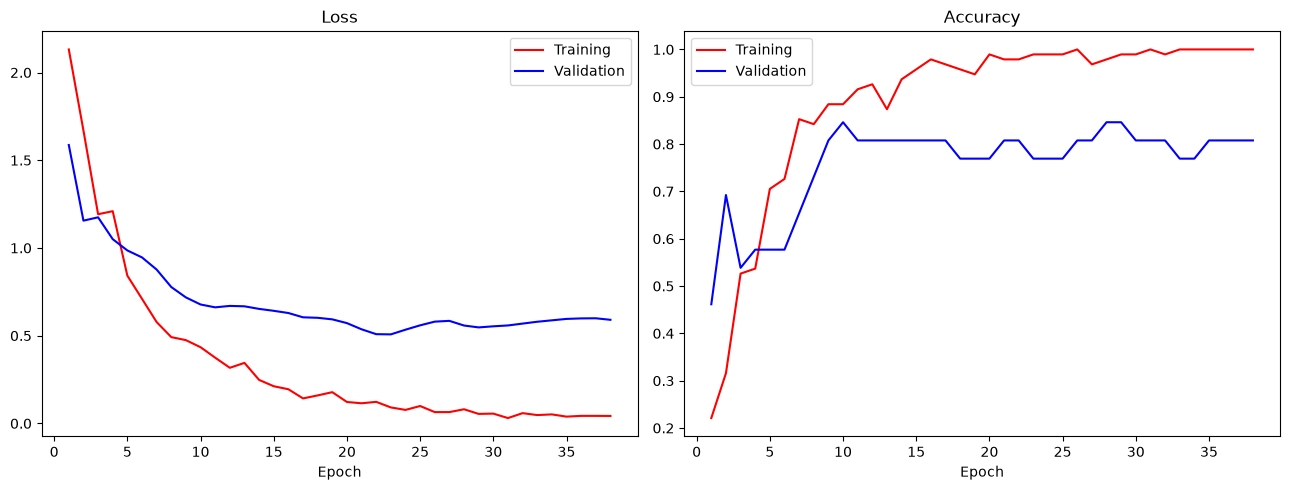

In [11]:
h = history.history
ep = range(1, len(h['loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(ep, h['loss'], 'r', label='Training')
axes[0].plot(ep, h['val_loss'], 'b', label='Validation')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(ep, h['accuracy'], 'r', label='Training')
axes[1].plot(ep, h['val_accuracy'], 'b', label='Validation')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.tight_layout()

save_path = os.path.join(RESULTS_DIR, 'training_curves.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f"Tersimpan: {save_path}")

plt.show()


## Evaluasi pada validation

Tersimpan: results\confusion_matrix_validation.png


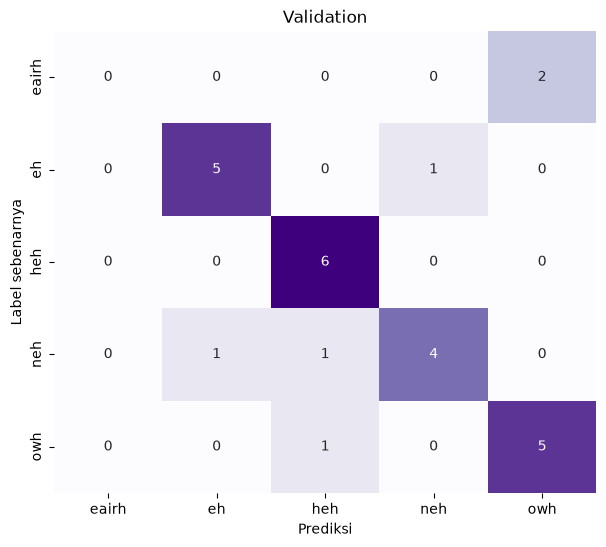

              precision    recall  f1-score   support

       eairh     0.0000    0.0000    0.0000         2
          eh     0.8333    0.8333    0.8333         6
         heh     0.7500    1.0000    0.8571         6
         neh     0.8000    0.6667    0.7273         6
         owh     0.7143    0.8333    0.7692         6

    accuracy                         0.7692        26
   macro avg     0.6195    0.6667    0.6374        26
weighted avg     0.7148    0.7692    0.7355        26

Accuracy : 0.7692
Macro F1 : 0.6374
Tersimpan: results\confusion_matrix_validation.txt


In [12]:
def report(dataset, df, judul, cmap, save_name):
    y_true = df['label'].values
    y_pred = np.argmax(model.predict(dataset, verbose=0), axis=1)

    plt.figure(figsize=(7, 6))
    sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cbar=False, cmap=cmap,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.ylabel('Label sebenarnya'); plt.xlabel('Prediksi'); plt.title(judul)

    png_path = os.path.join(RESULTS_DIR, f'{save_name}.png')
    plt.savefig(png_path, dpi=150, bbox_inches='tight')
    print(f"Tersimpan: {png_path}")
    plt.show()

    report_text = classification_report(y_true, y_pred, target_names=CLASS_NAMES,
                                        digits=4, zero_division=0)
    acc = (y_true == y_pred).mean()
    macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

    print(report_text)
    print(f"Accuracy : {acc:.4f}")
    print(f"Macro F1 : {macro_f1:.4f}")

    txt_path = os.path.join(RESULTS_DIR, f'{save_name}.txt')
    with open(txt_path, 'w') as f:
        f.write(f"{judul}\n\n")
        f.write(report_text)
        f.write(f"\nAccuracy : {acc:.4f}\n")
        f.write(f"Macro F1 : {macro_f1:.4f}\n")
    print(f"Tersimpan: {txt_path}")

report(valid_dataset, valid_df, 'Validation', 'Purples', save_name='confusion_matrix_validation')


## Evaluasi Test Set

Tersimpan: results\confusion_matrix_test.png


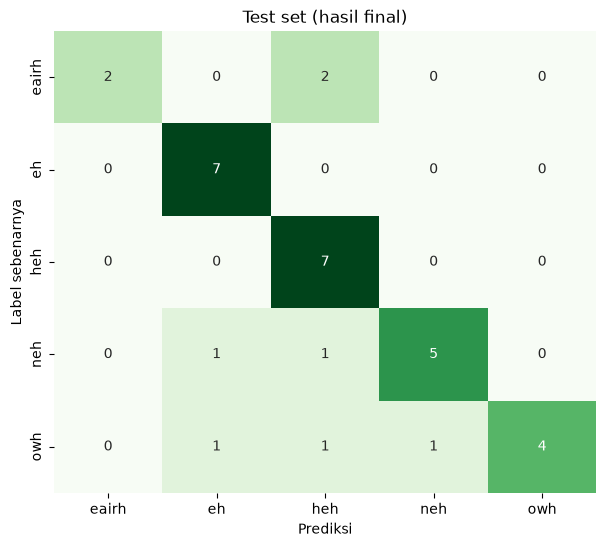

              precision    recall  f1-score   support

       eairh     1.0000    0.5000    0.6667         4
          eh     0.7778    1.0000    0.8750         7
         heh     0.6364    1.0000    0.7778         7
         neh     0.8333    0.7143    0.7692         7
         owh     1.0000    0.5714    0.7273         7

    accuracy                         0.7812        32
   macro avg     0.8495    0.7571    0.7632        32
weighted avg     0.8354    0.7812    0.7722        32

Accuracy : 0.7812
Macro F1 : 0.7632
Tersimpan: results\confusion_matrix_test.txt


In [13]:
_test_result_path = os.path.join(RESULTS_DIR, 'confusion_matrix_test.txt')
if os.path.exists(_test_result_path):
    raise FileExistsError(
        f"'{_test_result_path}' sudah ada, test set sudah pernah dievaluasi untuk run ini.\n"
    )

report(test_dataset, test_df, 'Test set (hasil final)', 'Greens', save_name='confusion_matrix_test')


## Simpan model & inferensi video baru

In [14]:
model.save('tangis_bayi_fusion.keras')

def predict_video(video_path):
    result = extract_video_sample(
        video_path,
        os.path.join(WORK_DIR, 'infer_frame'),
        os.path.join(WORK_DIR, 'infer_spec'),
    )
    if result is None:
        raise ValueError("Gagal mengekstrak citra/audio dari video ini.")
    frame_paths, spec_path = result

    frames = tf.expand_dims(tf.stack([load_frame(p) for p in frame_paths]), 0)
    spec   = tf.expand_dims(load_spec(spec_path), 0)

    probs = model.predict([frames, spec], verbose=0)[0]
    for cls, p in sorted(zip(CLASS_NAMES, probs), key=lambda kv: -kv[1]):
        print(f"{cls:3s} ({MEANINGS[cls]:16s}) : {p:.4f}")
    hasil = CLASS_NAMES[int(np.argmax(probs))]
    print(f"\nPrediksi: {hasil} — {MEANINGS[hasil]}")
    return hasil

predict_video('tes.mp4')

heh (Tidak nyaman    ) : 0.8726
neh (Lapar           ) : 0.1056
eh  (Perlu bersendawa) : 0.0150
eairh (Masuk angin     ) : 0.0058
owh (Mengantuk       ) : 0.0010

Prediksi: heh — Tidak nyaman


'heh'